In [49]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_groq import ChatGroq
from typing import TypedDict
from dotenv import load_dotenv
import os

In [50]:
load_dotenv(override=True)

True

In [51]:
# model = ChatOpenAI()

In [52]:
model = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=os.getenv("GROQ_API_KEY")
)

In [53]:
# create a state

class LLMState(TypedDict):
    question: str
    answer: str

In [54]:
def llm_qa(state: LLMState) -> LLMState:

    #extract the question from state
    question = state['question']

    # form a prompt
    prompt = f'Answer the following question {question}'

    # ask that question to the LLM
    answer = model.invoke(prompt).content

    # ask that question to the LLM
    state['answer'] = answer

    return state

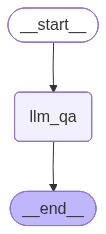

In [55]:
# create our graph
graph = StateGraph(LLMState)

# add nodes
graph.add_node('llm_qa', llm_qa)

# add edges
graph.add_edge(START, 'llm_qa')
graph.add_edge('llm_qa', END)

graph.compile()

In [56]:
workflow = graph.compile()

In [57]:
output_state = workflow.invoke({"question": "Who is Elon Musk"})
print(output_state['answer'])

**Elon Musk: A Visionary Entrepreneur and Innovator**

Elon Musk is a South African-born entrepreneur, inventor, and business magnate who has revolutionized multiple industries through his innovative ventures and ideas. He is best known for his ambitious goals and vision for a sustainable future, which has made him a household name and a leading figure in the tech and business world.

**Early Life and Education**

Born on June 28, 1971, in Pretoria, South Africa, Musk grew up with a passion for reading and learning. He taught himself computer programming and, at the age of 12, created his first software program, a space-themed video game called Blastar. Musk moved to Canada in 1992 to attend college and later transferred to the University of Pennsylvania, where he graduated with a degree in economics and physics.

**Career**

Musk's career is marked by a series of successful ventures:

1. **Zip2** (1995): Musk co-founded Zip2, a software company that provided online content publishing 

In [58]:
import os
from langchain_groq import ChatGroq

llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=os.getenv("GROQ_API_KEY")
)

print(llm.invoke("What is LangGraph?").content)

LangGraph is an open-source, large language model developed by the LangGraph team. It's designed to process and understand human language, similar to other popular models like LLaMA or BERT. The model's primary function is to generate text based on the input it receives, making it useful for a variety of applications such as chatbots, language translation, and content creation.

As LangGraph is open-source, the model and its training data are freely available for anyone to use, modify, and distribute. This allows developers and researchers to build upon and improve the model, potentially leading to advancements in natural language processing (NLP) and other related fields.

Some key features of LangGraph include:

1. **Text generation**: LangGraph can create coherent and context-specific text based on a given prompt or input.
2. **Language understanding**: The model is trained on a vast amount of text data, allowing it to comprehend and interpret human language.
3. **Customizability**: